In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

In [13]:
# ======================================================
# CLUSTER FILE DICTIONARY  
# ======================================================

cluster_files = {

    "NGC 2287": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2287_final.csv",
    "Collinder 69": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Collinder_69_final (1).csv",
    "Collinder 261": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Collinder_261_final.csv",
    "IC 4651": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/IC_4651_final.csv",
    "Melotte 20": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Melotte_20_final.csv",
    "Melotte 22": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Melotte_22_final.csv",
    "Melotte 101": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Melotte_101_final.csv",
    "NGC 188": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_188_final.csv",
    "NGC 1039": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_1039_final.csv",
    "NGC 1647": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_1647_final.csv",
    "NGC 2112": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2112_final.csv",
    "NGC 2477": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2477_final.csv",
    "NGC 2516": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2516_final.csv",
    "NGC 2539": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2539_final.csv",
    "NGC 2632": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2632_final.csv",
    "NGC 2682": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2682_final.csv",
    "NGC 6124": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_6124_final.csv",
    "NGC 6819": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_6819_final.csv",
    "NGC 6939": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_6939_final.csv",
    "NGC 6940": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_6940_final.csv",
    "NGC 7789": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_7789_final.csv"

}


In [14]:
# ======================================================
# LOAD CENTRE TABLE
# ======================================================

centres = pd.read_csv(
    "/Users/prernadwivedi/Downloads/21 clusters/cluster_centres_with_distance.csv"
)

centres["Cluster_clean"] = (
    centres["Cluster"]
    .str.replace(" ", "", regex=False)
    .str.replace("_", "", regex=False)
    .str.replace("-", "", regex=False)
    .str.upper()
)

In [15]:
# ======================================================
# PLOT SAVE LOCATION
# ======================================================

plot_folder = "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/king_cumulative_plots/"
os.makedirs(plot_folder, exist_ok=True)

In [16]:

# ======================================================
# ANGULAR SEPARATION
# ======================================================

def angular_sep(ra1, dec1, ra2, dec2):
    ra1 = np.radians(ra1)
    dec1 = np.radians(dec1)
    ra2 = np.radians(ra2)
    dec2 = np.radians(dec2)

    cos_theta = (
        np.sin(dec1)*np.sin(dec2)
        + np.cos(dec1)*np.cos(dec2)*np.cos(ra1-ra2)
    )
    cos_theta = np.clip(cos_theta, -1, 1)
    return np.arccos(cos_theta)

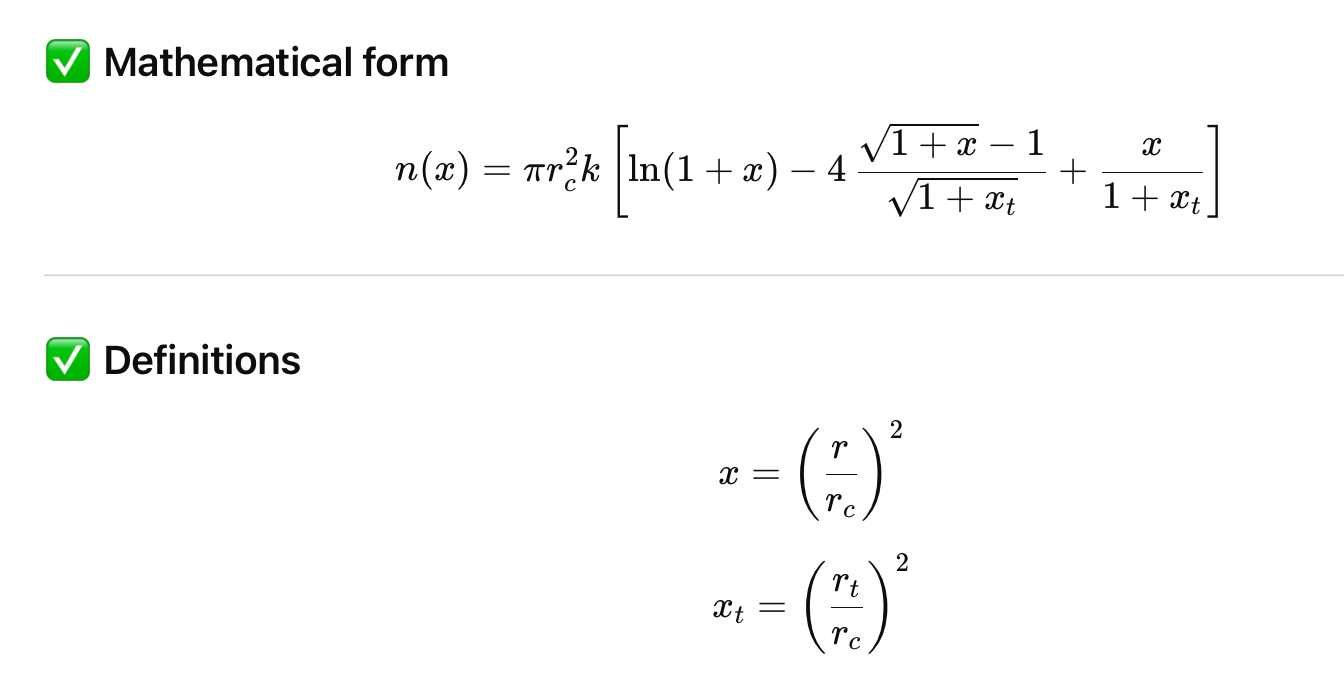

In [17]:

# ======================================================
# KING MODEL
# ======================================================

def king_cumulative(r, rc, rt, k):
   

  
    x = (r / rc)**2
    xt = (rt / rc)**2

    return np.pi * rc**2 * k * (
        np.log(1 + x)
        - 4 * (np.sqrt(1 + x) - 1) / np.sqrt(1 + xt)
        + x / (1 + xt)
    )

In [18]:

# ======================================================
# RESULTS
# ======================================================

king_results = {}

In [19]:
rc_initial_dict = {
"Collinder 69": 13.47,
"Collinder 261": 20.57,
"IC 4651": 16.11,
"Melotte 20": 18.31,
"Melotte 22": 15.93,
"Melotte 101": 18.64,
"NGC 188": 60.91,
"NGC 1039": 16.47,
"NGC 1647": 11.95,
"NGC 2112": 9.48,
"NGC 2287": 13.62,
"NGC 2477": 13.31,
"NGC 2516": 19.91,
"NGC 2539": 13.56,
"NGC 2632": 13.91,
"NGC 2682": 7.43,
"NGC 6124": 12.84,
"NGC 6819": 11.13,
"NGC 6939": 15.25,
"NGC 6940": 14.16,
"NGC 7789": 11.79
}


Processing: NGC 2287


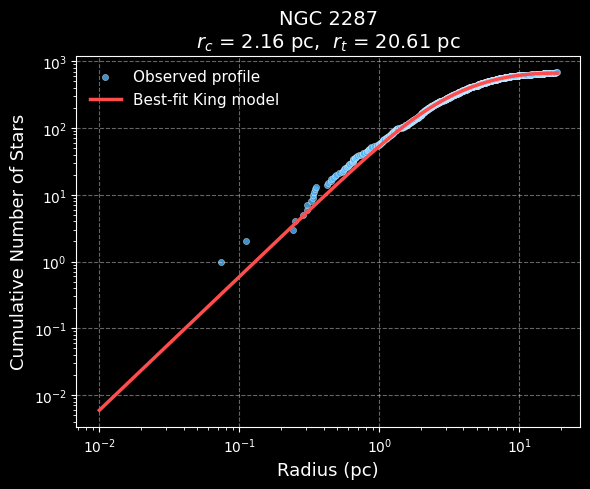


Processing: Collinder 69


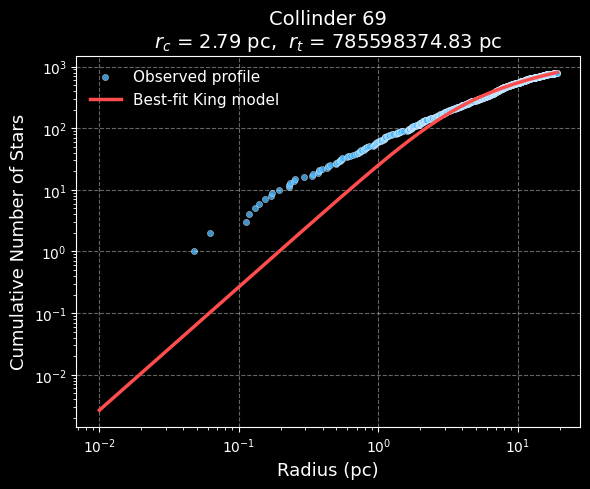


Processing: Collinder 261


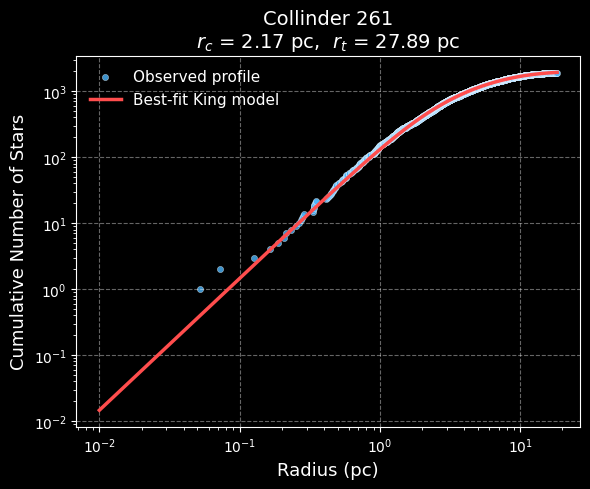


Processing: IC 4651


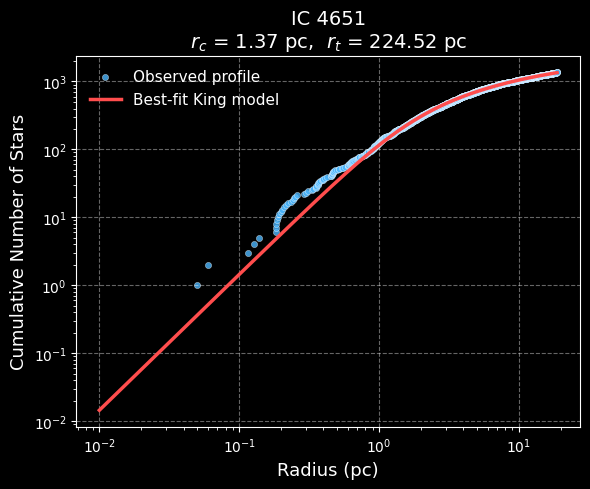


Processing: Melotte 20


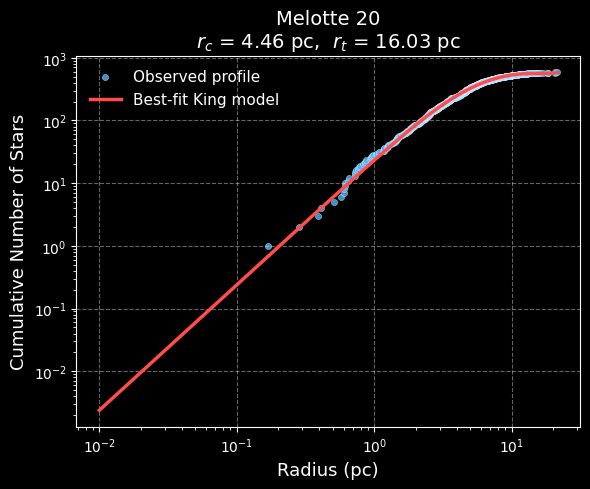


Processing: Melotte 22


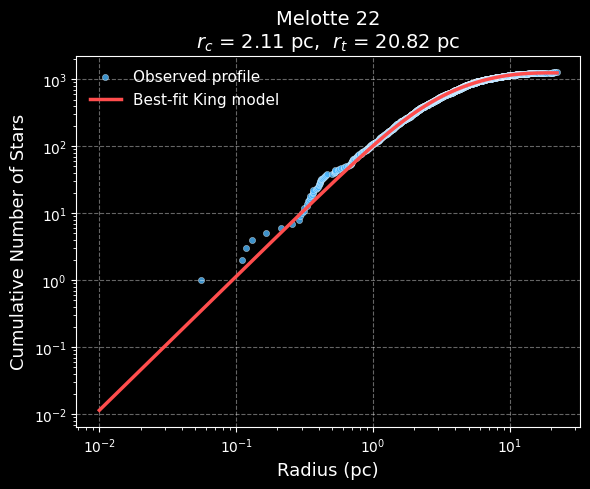


Processing: Melotte 101


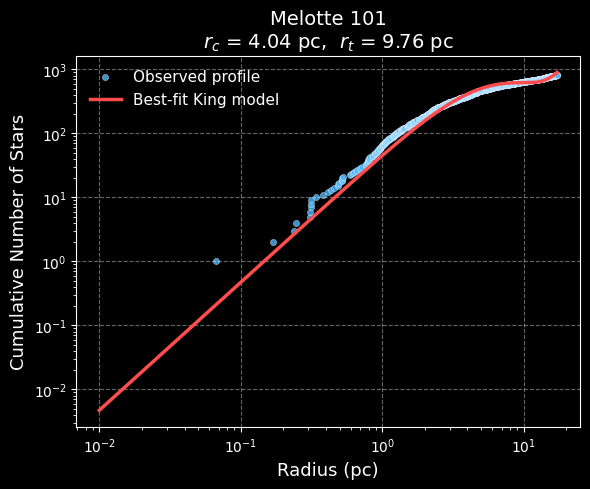


Processing: NGC 188


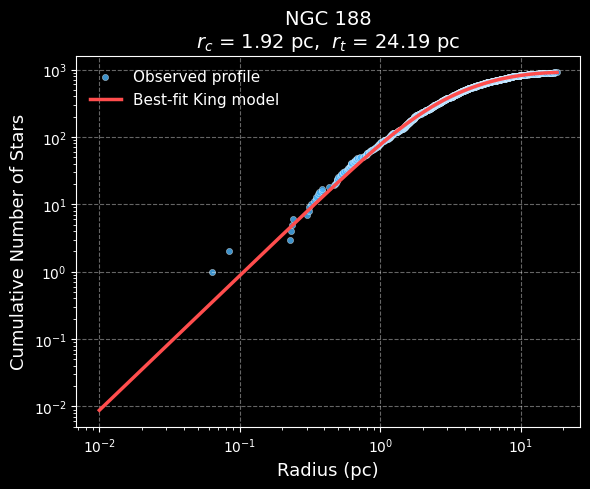


Processing: NGC 1039


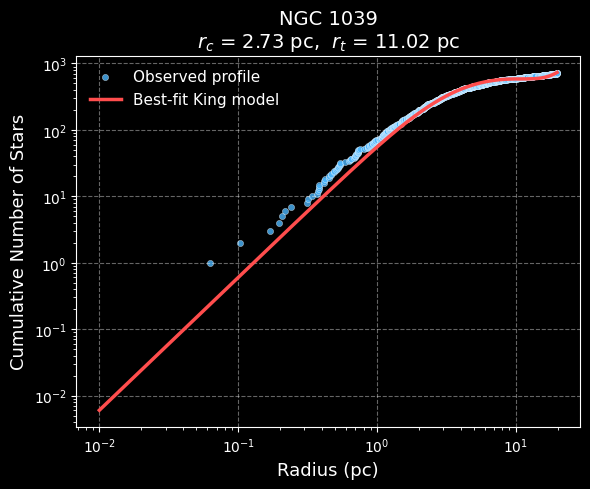


Processing: NGC 1647


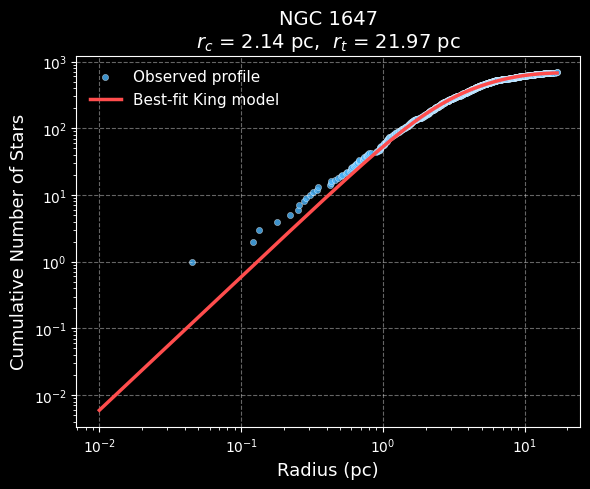


Processing: NGC 2112


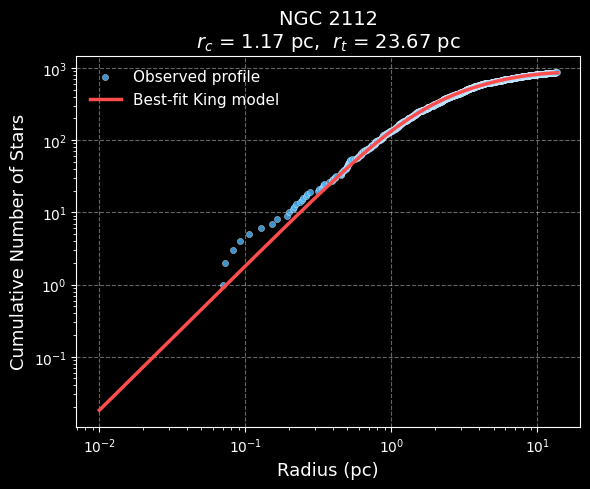


Processing: NGC 2477


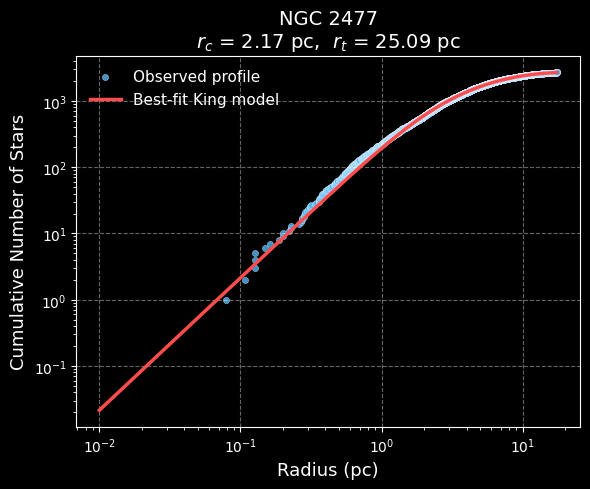


Processing: NGC 2516


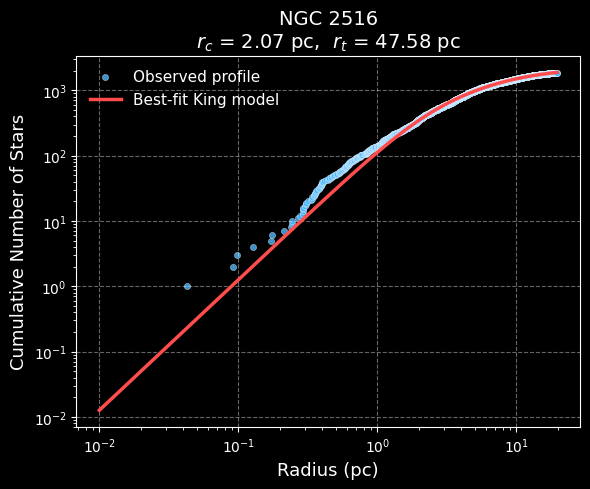


Processing: NGC 2539


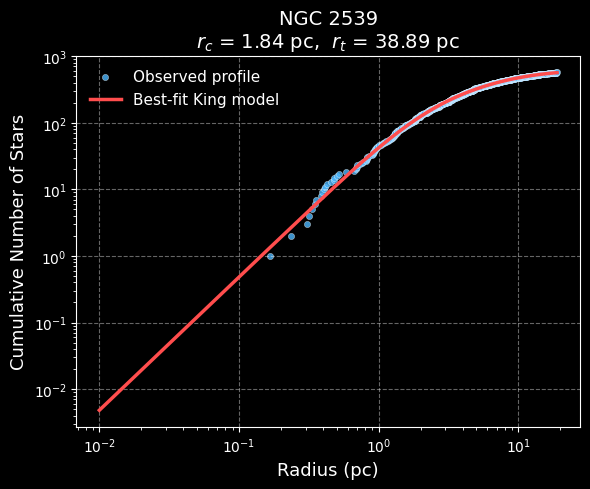


Processing: NGC 2632


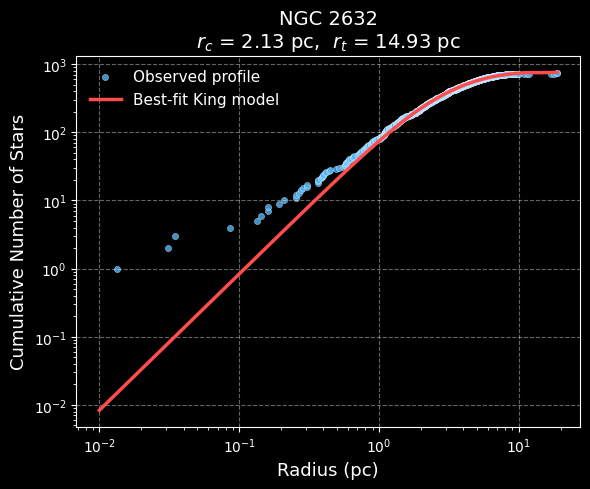


Processing: NGC 2682


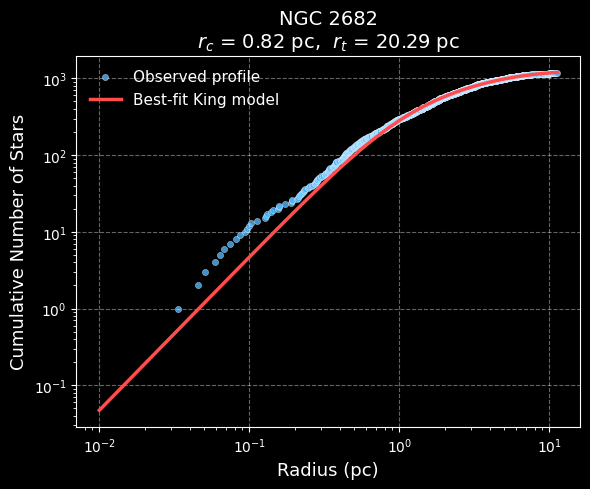


Processing: NGC 6124


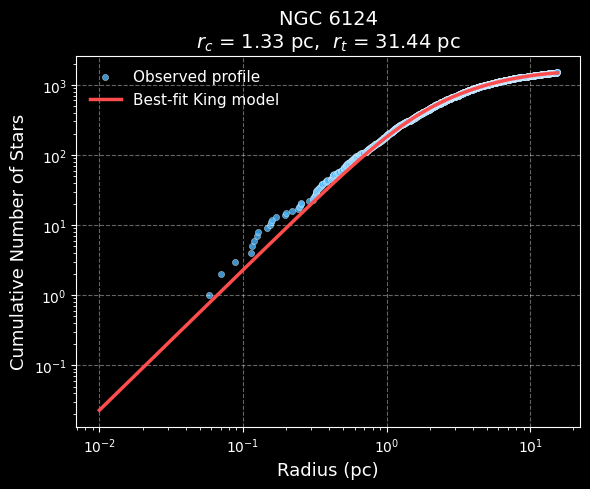


Processing: NGC 6819


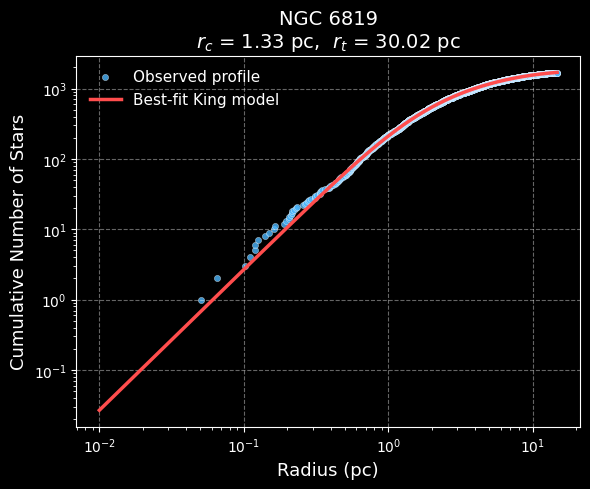


Processing: NGC 6939


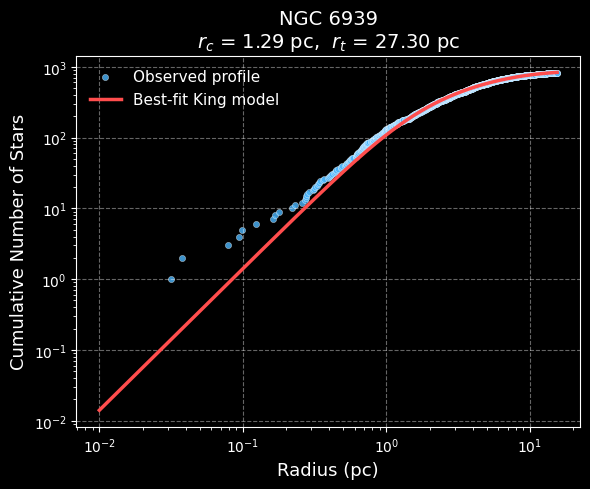


Processing: NGC 6940


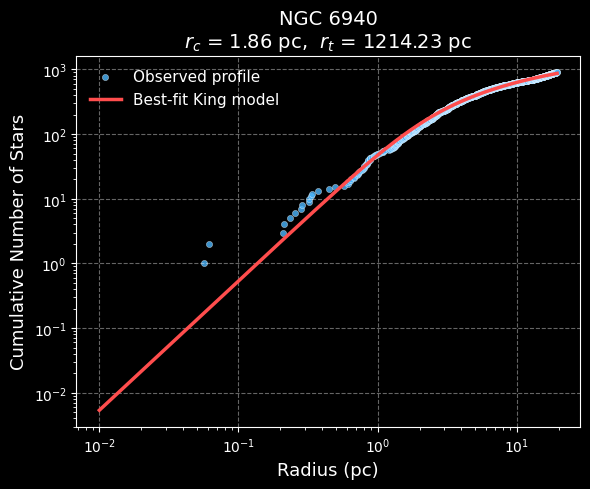


Processing: NGC 7789


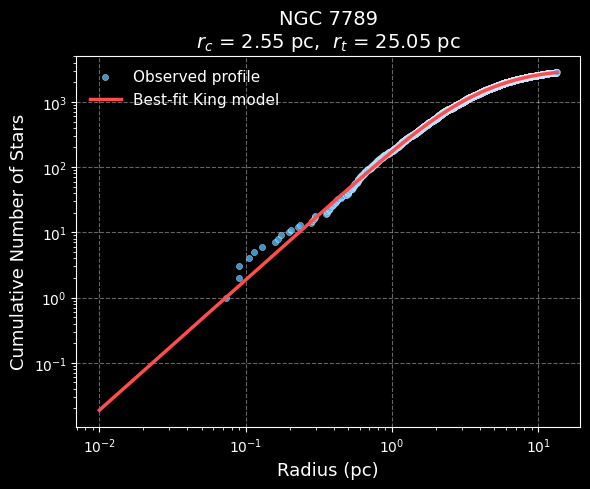

In [20]:
# ======================================================
# MAIN LOOP
# ======================================================

for cluster_name, file_path in cluster_files.items():

    print("\nProcessing:", cluster_name)

    # -------------------------------
    # Load star data
    # -------------------------------
    stars = pd.read_csv(file_path)

    # -------------------------------
    # Match cluster with centre catalogue
    # -------------------------------
    cluster_clean = cluster_name.replace(" ", "").upper()
    row = centres[centres["Cluster_clean"] == cluster_clean]

    if len(row) == 0:
        print("Cluster not found")
        continue

    row = row.iloc[0]

    # External priors from re_estimated_centres.csv
    distance_pc = row["distance_pc"]
    membership_threshold = row["Membership_threshold"]

    # -------------------------------
    # Membership selection
    # -------------------------------
    members = stars[
        stars["cluster_membership"] >= membership_threshold
    ].copy()

    # -------------------------------
    # Calculate angular separation and convert to physical radius
    # -------------------------------
    theta = angular_sep(
        members["RA_ICRS"],
        members["DE_ICRS"],
        row["RA_KDE_deg"],
        row["Dec_KDE_deg"]
    )

    members["r_pc"] = distance_pc * theta

    # -------------------------------
    # Sort by radius and build cumulative counts
    # -------------------------------
    members = members.sort_values("r_pc").reset_index(drop=True)

    r = members["r_pc"].values
    N = np.arange(1, len(r) + 1)

    # -------------------------------
    # Initial guesses
    # -------------------------------
    rc_guess = rc_initial_dict.get(cluster_name)

    if rc_guess is None:
        rc_guess = np.percentile(r, 20)

    rt_guess = np.percentile(r, 90)

    k_guess = len(r) / (np.pi * rc_guess**2)

    # -------------------------------
    # Fit cumulative King profile
    # -------------------------------
    popt, pcov = curve_fit(
        king_cumulative,
        r,
        N,
        p0=[rc_guess, rt_guess, k_guess],
        bounds=([1e-3, 1e-2, 1e-6], [np.inf, np.inf, np.inf]),
        maxfev=200000
    )

    rc, rt, k = popt
    rc_err, rt_err, _ = np.sqrt(np.diag(pcov))
    c = rt / rc

    # -------------------------------------------------
    # King Profile Plot
    # -------------------------------------------------


    r_plot = np.maximum(r, 0.01)

    r_fit = np.linspace(0.01, r.max(), 500)
    N_fit = king_cumulative(r_fit, *popt)

    plt.figure(figsize=(6,5))

    plt.scatter(
        r_plot,
        N,
        s=20,
        color="#4db8ff",
        alpha=0.8,
        edgecolors="white",
        linewidth=0.3,
        label="Observed profile"
    )

    plt.plot(
        r_fit,
        N_fit,
        color="#ff4d4d",
        linewidth=2.5,
        label="Best-fit King model"
    )

    plt.xscale("log")
    plt.yscale("log")

    plt.xlabel("Radius (pc)", fontsize=13)
    plt.ylabel("Cumulative Number of Stars", fontsize=13)

    plt.title(
        f"{cluster_name}\n$r_c$ = {rc:.2f} pc,  $r_t$ = {rt:.2f} pc",
        fontsize=14
    )

    plt.grid(True, linestyle="--", alpha=0.4)

    plt.legend(frameon=False, fontsize=11)

    plt.tight_layout()

    plt.savefig(
        plot_folder + cluster_clean + "_king.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # -------------------------------
    # Store results
    # -------------------------------
    king_results[cluster_name] = {
        "rc_pc": rc,
        "rc_err": rc_err,
        "rt_pc": rt,
        "rt_err": rt_err,
        "k": k,
        "concentration": c,
        "N_members": len(r)
    }

In [21]:
# ======================================================
# RESULTS TABLE
# ======================================================

king_results_df = pd.DataFrame(king_results).T   # transpose so clusters are rows
king_results_df.reset_index(inplace=True)
king_results_df.rename(columns={"index": "Cluster"}, inplace=True)

print("\n===== KING MODEL STRUCTURAL PARAMETERS =====\n")
print(king_results_df)


===== KING MODEL STRUCTURAL PARAMETERS =====

          Cluster     rc_pc    rc_err         rt_pc        rt_err           k  \
0        NGC 2287  2.156173  0.009231  2.061481e+01  1.255702e-01   23.529296   
1    Collinder 69  2.791032  0.023404  7.855984e+08  2.081071e-17    8.461830   
2   Collinder 261  2.174233  0.003622  2.789213e+01  9.536560e-02   54.618612   
3         IC 4651  1.368524  0.004317  2.245163e+02  1.018962e+01   46.402849   
4      Melotte 20  4.455799  0.037284  1.602776e+01  1.218058e-01   14.210090   
5      Melotte 22  2.109468  0.005766  2.081559e+01  8.524908e-02   45.106970   
6     Melotte 101  4.040267  0.050333  9.763186e+00  4.454150e-02   39.359996   
7         NGC 188  1.917599  0.005155  2.418937e+01  1.212812e-01   32.984097   
8        NGC 1039  2.730087  0.024981  1.102131e+01  6.112883e-02   33.135794   
9        NGC 1647  2.135742  0.013340  2.197241e+01  2.203625e-01   23.105257   
10       NGC 2112  1.166557  0.004807  2.366935e+01  2.194205e

In [22]:
# ======================================================
# CONVERT RESULTS DICTIONARY TO TABLE
# ======================================================

king_df = pd.DataFrame.from_dict(king_results, orient="index")

# move cluster names from index to a column
king_df = king_df.reset_index()
king_df = king_df.rename(columns={"index": "Cluster"})


# ======================================================
# SAVE CSV FILE
# ======================================================

king_df.to_csv("king_profile_results.csv", index=False)


print("Saved file: king_profile_results.csv")
print(king_df)


Saved file: king_profile_results.csv
          Cluster     rc_pc    rc_err         rt_pc        rt_err           k  \
0        NGC 2287  2.156173  0.009231  2.061481e+01  1.255702e-01   23.529296   
1    Collinder 69  2.791032  0.023404  7.855984e+08  2.081071e-17    8.461830   
2   Collinder 261  2.174233  0.003622  2.789213e+01  9.536560e-02   54.618612   
3         IC 4651  1.368524  0.004317  2.245163e+02  1.018962e+01   46.402849   
4      Melotte 20  4.455799  0.037284  1.602776e+01  1.218058e-01   14.210090   
5      Melotte 22  2.109468  0.005766  2.081559e+01  8.524908e-02   45.106970   
6     Melotte 101  4.040267  0.050333  9.763186e+00  4.454150e-02   39.359996   
7         NGC 188  1.917599  0.005155  2.418937e+01  1.212812e-01   32.984097   
8        NGC 1039  2.730087  0.024981  1.102131e+01  6.112883e-02   33.135794   
9        NGC 1647  2.135742  0.013340  2.197241e+01  2.203625e-01   23.105257   
10       NGC 2112  1.166557  0.004807  2.366935e+01  2.194205e-01   63.9

In [23]:
import pandas as pd

centres = pd.read_csv("cluster_centres_with_distance.csv")
king = pd.read_csv("king_profile_results.csv")


In [24]:
def clean_name(s):
    return (s.astype(str)
             .str.strip()
             .str.lower()
             .str.replace("_", " ", regex=False))

centres["Cluster_clean"] = clean_name(centres["Cluster"])
king["Cluster_clean"]    = clean_name(king["Cluster"])

In [25]:
final = centres.merge(
    king,
    on="Cluster_clean",
    how="inner",
    suffixes=("_centre", "_king")
)

In [26]:
final["Cluster"] = final["Cluster_centre"]

In [27]:
final["concentration"] = final["rt_pc"] / final["rc_pc"]

In [28]:
table = final[[
    "Cluster",
    "RA_KDE_deg",
    "Dec_KDE_deg",
    "Members_after_cut",   # or N_members if that’s what you saved
    "rc_pc",
    "rc_err",
    "rt_pc",
    "rt_err",
    "concentration"
]]

In [29]:
table = table.round({
    "RA_KDE_deg": 4,
    "Dec_KDE_deg": 4,
    "rc_pc": 2,
    "rc_err": 2,
    "rt_pc": 2,
    "rt_err": 2,
    "concentration": 2
})

In [30]:
table.to_csv("final_cluster_structural_table.csv", index=False)

In [32]:
final_cluster_structural_table.csv_to_latex(
    "final_cluster_structural_table.tex",
    index=False,
    float_format="%.2f",
    column_format="lcccccccc"
)

NameError: name 'final_cluster_structural_table' is not defined